<a href="https://colab.research.google.com/github/harshs-data/Machine-Learning/blob/main/Naive_bayes_basic_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
data = {
    'email': ['apply data science course for free', 'win 2000 for free', 'win scooty by applying the contest', 'trip to lakshadweep for free','hey harsh how are you', 'hey whats up bro', 'tomorrow is holiday', 'sleep alarm'],
    'classification': ['spam', 'spam', 'spam', 'spam', 'ham', 'ham', 'ham', 'ham']
}

In [18]:
import numpy as np
import pandas as pd


In [19]:
df = pd.DataFrame(data)
df

,email,classification
0,apply data science course for free,spam
1,win 2000 for free,spam
2,win scooty by applying the contest,spam
3,trip to lakshadweep for free,spam
4,hey harsh how are you,ham
5,hey whats up bro,ham
6,tomorrow is holiday,ham
7,sleep alarm,ham


In [20]:
df.shape

(8, 2)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   email           8 non-null      object
 1   classification  8 non-null      object
dtypes: object(2)
memory usage: 260.0+ bytes


In [22]:
df.describe()

,email,classification
count,8,8
unique,8,2
top,apply data science course for free,spam
freq,1,4


In [23]:
X = df['email']
y = df['classification']

In [24]:
print(X)

0    apply data science course for free
1                     win 2000 for free
2    win scooty by applying the contest
3          trip to lakshadweep for free
4                 hey harsh how are you
5                      hey whats up bro
6                   tomorrow is holiday
7                           sleep alarm
Name: email, dtype: object


In [25]:
y

,classification
0,spam
1,spam
2,spam
3,spam
4,ham
5,ham
6,ham
7,ham


In [26]:
from sklearn.naive_bayes import MultinomialNB

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [29]:
nb = MultinomialNB()
nb.fit(X_train_vectorized, y_train)


MultinomialNB()

In [34]:
y_pred = nb.predict(X_test_vectorized)

In [51]:
print('Test Text: \n', pd.DataFrame(X_test))
print('Predictions: ', y_pred)

Test Text: 
                email
1  win 2000 for free
5   hey whats up bro
Predictions:  ['spam' 'ham']


In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = nb.predict(X_test_vectorized)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [45]:
query_sample = ['how are you harsh', 'win free certification of data science course']
query_sample_vectorized = vectorizer.transform(query_sample)
prediction = nb.predict(query_sample_vectorized)
print(prediction)


['ham' 'spam']


In [46]:
print(f"Total vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Vocabulary: {vectorizer.vocabulary_}")

Total vocabulary size: 25
Vocabulary: {'apply': 1, 'data': 7, 'science': 16, 'course': 6, 'for': 8, 'free': 9, 'sleep': 18, 'alarm': 0, 'win': 23, 'scooty': 17, 'by': 4, 'applying': 2, 'the': 19, 'contest': 5, 'hey': 11, 'harsh': 10, 'how': 13, 'are': 3, 'you': 24, 'trip': 22, 'to': 20, 'lakshadweep': 15, 'tomorrow': 21, 'is': 14, 'holiday': 12}


/tmp/ipykernel_1580/1636586927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_counts.index, y=classification_counts.values, palette='viridis')


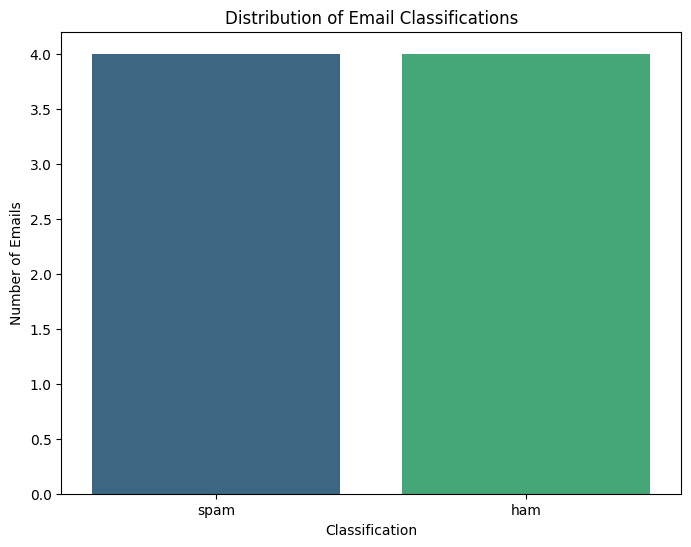

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts of the 'classification' column
classification_counts = df['classification'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=classification_counts.index, y=classification_counts.values, palette='viridis')
plt.title('Distribution of Email Classifications')
plt.xlabel('Classification')
plt.ylabel('Number of Emails')
plt.show()

In [53]:
feature_names = vectorizer.get_feature_names_out()

# Get log probabilities for each class
ham_prob_features = nb.feature_log_prob_[0] # Assuming 0 is 'ham'
spam_prob_features = nb.feature_log_prob_[1] # Assuming 1 is 'spam'

# Create DataFrames for better visualization
ham_df = pd.DataFrame({'word': feature_names, 'probability': np.exp(ham_prob_features)})
spam_df = pd.DataFrame({'word': feature_names, 'probability': np.exp(spam_prob_features)})

# Sort by probability and display top words for each class
top_ham_words = ham_df.sort_values(by='probability', ascending=False).head(10)
top_spam_words = spam_df.sort_values(by='probability', ascending=False).head(10)

print("\nTop 10 words in Ham emails:")
display(top_ham_words)

print("\nTop 10 words in Spam emails:")
display(top_spam_words)


Top 10 words in Ham emails:


,word,probability
0,alarm,0.057143
3,are,0.057143
21,tomorrow,0.057143
24,you,0.057143
14,is,0.057143
13,how,0.057143
12,holiday,0.057143
11,hey,0.057143
10,harsh,0.057143
18,sleep,0.057143



Top 10 words in Spam emails:


,word,probability
8,for,0.071429
9,free,0.071429
6,course,0.047619
4,by,0.047619
1,apply,0.047619
7,data,0.047619
5,contest,0.047619
16,science,0.047619
2,applying,0.047619
22,trip,0.047619


/tmp/ipykernel_1580/3878231294.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='probability', y='word', data=top_ham_words, palette='GnBu_r')
/tmp/ipykernel_1580/3878231294.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='probability', y='word', data=top_spam_words, palette='YlOrRd_r')


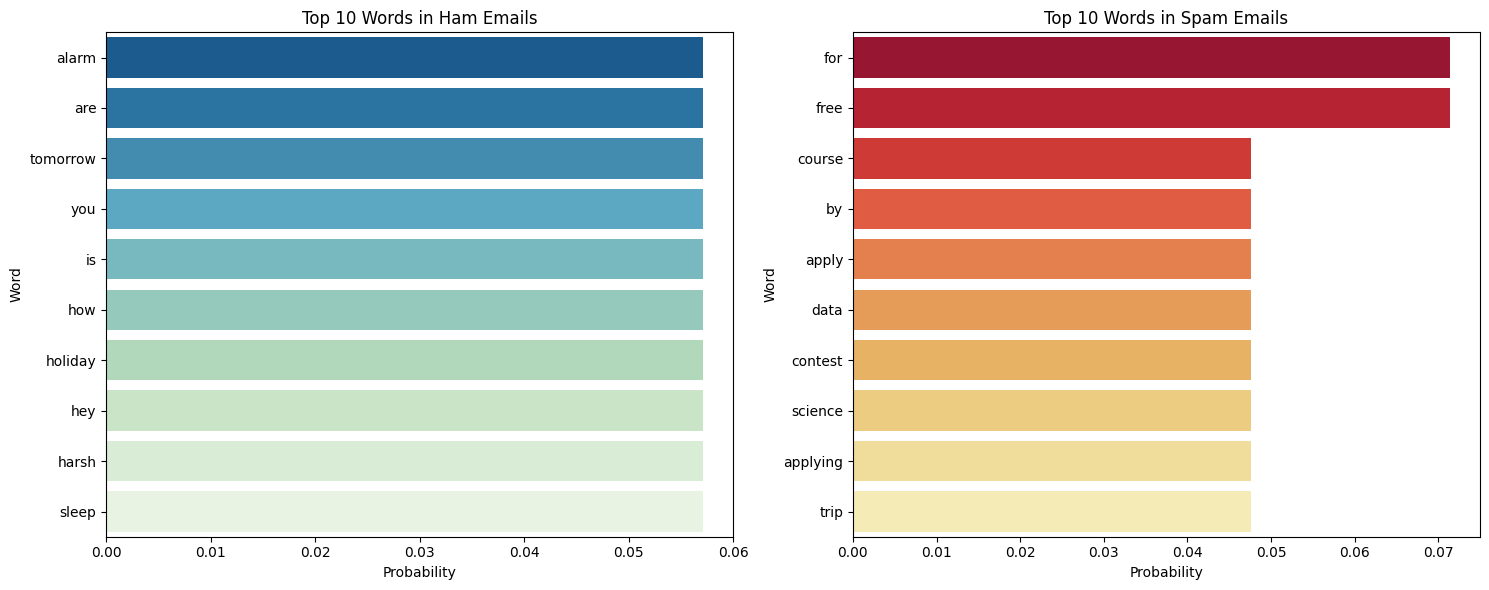

In [54]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='probability', y='word', data=top_ham_words, palette='GnBu_r')
plt.title('Top 10 Words in Ham Emails')
plt.xlabel('Probability')
plt.ylabel('Word')

plt.subplot(1, 2, 2)
sns.barplot(x='probability', y='word', data=top_spam_words, palette='YlOrRd_r')
plt.title('Top 10 Words in Spam Emails')
plt.xlabel('Probability')
plt.ylabel('Word')

plt.tight_layout()
plt.show()